## Contexto:

Este projeto tem como objetivo analisar uma base de clientes contendo informações demográficas e financeiras — como país, gênero, score de crédito, idade, saldo e comportamento de consumo.

A partir dessa análise, busca-se identificar padrões associados ao cancelamento de clientes (churn) e desenvolver um modelo de Machine Learning capaz de prever quais clientes possuem maior risco de evasão.

Com isso, a proposta é apoiar a tomada de decisão, permitindo a criação de estratégias mais assertivas de retenção e redução de churn.

### Etapa 1:

A primeira etapa em um projeto de machine learning é a obtenção de dados. A partir dessa obtenção, podemos fazer a leitura dos dados para se construir um modelo. Como tarefa inicial, faça a leitura da base de dados e verifique a presença de dados nulos.

In [75]:
import pandas as pd
import numpy as np

In [4]:
dados = pd.read_csv(r'C:\Users\ferna\Documents\Cursos\Alura\carreia_data_science\ML\dados\churn.csv')

In [5]:
dados

,id_cliente,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,15634602,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,França,Homem,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,França,Homem,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,França,Mulher,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Alemanha,Homem,42,3,75075.31,2,1,0,92888.52,1


In [6]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           10000 non-null  int64  
 1   score_credito        10000 non-null  int64  
 2   pais                 10000 non-null  object 
 3   sexo_biologico       10000 non-null  object 
 4   idade                10000 non-null  int64  
 5   anos_de_cliente      10000 non-null  int64  
 6   saldo                10000 non-null  float64
 7   servicos_adquiridos  10000 non-null  int64  
 8   tem_cartao_credito   10000 non-null  int64  
 9   membro_ativo         10000 non-null  int64  
 10  salario_estimado     10000 non-null  float64
 11  churn                10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


### etapa 2

Após a leitura dos dados, é importante conhecer os dados, checando inconsistências e entendendo o comportamento de cada uma das colunas. Neste etapa, faço uma análise exploratória utilizando gráficos para as **variáveis categóricas** da base de dados, incluindo a **variável alvo** churn.

In [7]:
import plotly.express as px

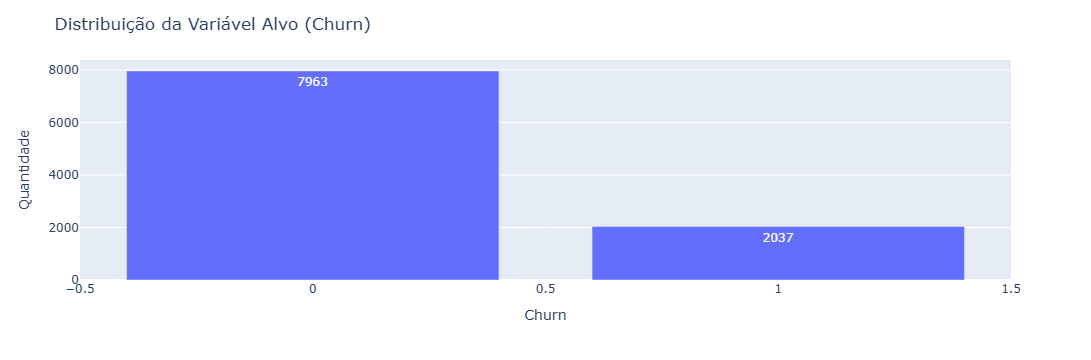

In [11]:

fig = px.bar(
    dados['churn'].value_counts().reset_index(),
    x='index',
    y='churn',
    text='churn'
)

fig.update_layout(xaxis_title='Churn', yaxis_title='Quantidade',title='Distribuição da Variável Alvo (Churn)'
    
)

fig.show()

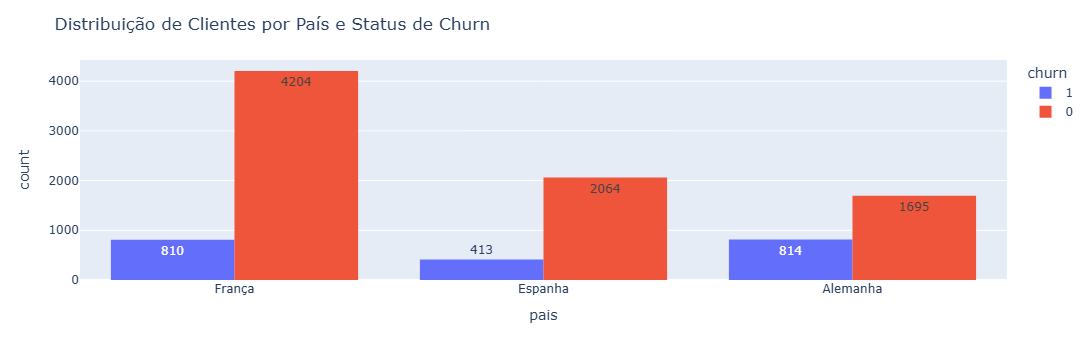

In [14]:
fig2 = px.histogram(dados, x = 'pais', text_auto = True, color = 'churn', barmode = 'group')

fig2.update_layout(
    title='Distribuição de Clientes por País e Status de Churn'
)

fig2.show()

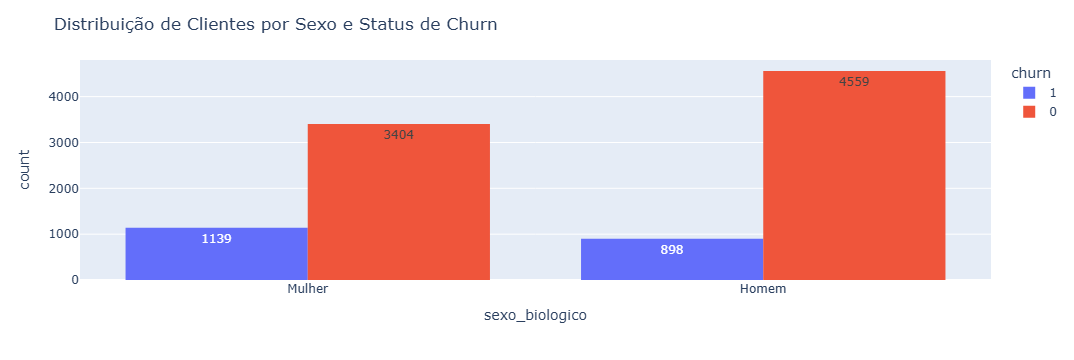

In [15]:
fig3 = px.histogram(dados, x = 'sexo_biologico', text_auto = True, color = 'churn', barmode = 'group')

fig3.update_layout(
    title='Distribuição de Clientes por Sexo e Status de Churn'
)

fig3.show()

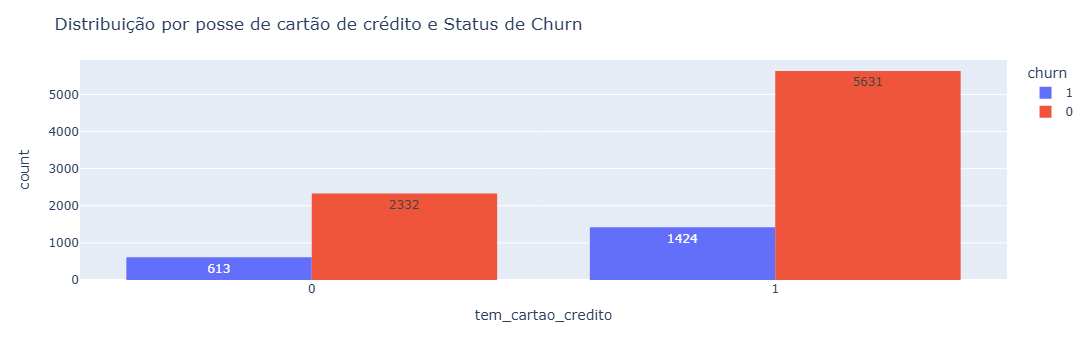

In [17]:
fig4 = px.histogram(dados, x = 'tem_cartao_credito', text_auto = True, color = 'churn', barmode = 'group')

fig4.update_layout(
    title='Distribuição por posse de cartão de crédito e Status de Churn'
)

fig4.show()

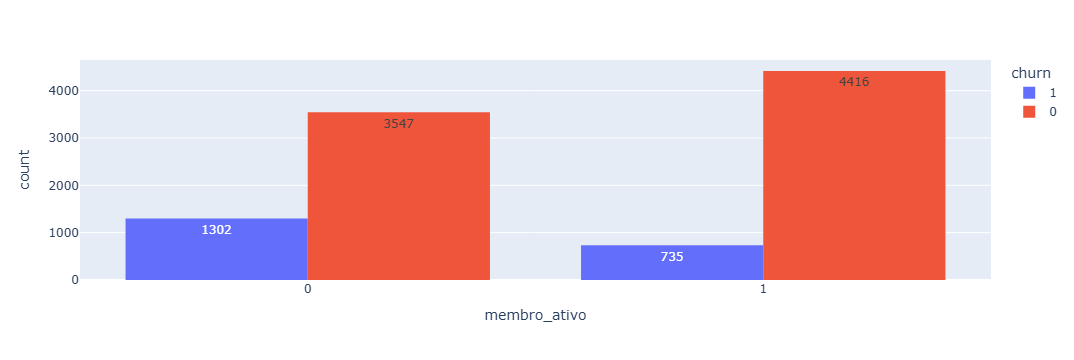

In [18]:
px.histogram(dados, x = 'membro_ativo', text_auto = True, color = 'churn', barmode = 'group')

### Etapa 3

Depois de explorar as variáveis categóricas, chegou a vez das **variáveis numéricas**. Analisando o comportamento dos valores numéricos e checar se existem valores inconsistentes.

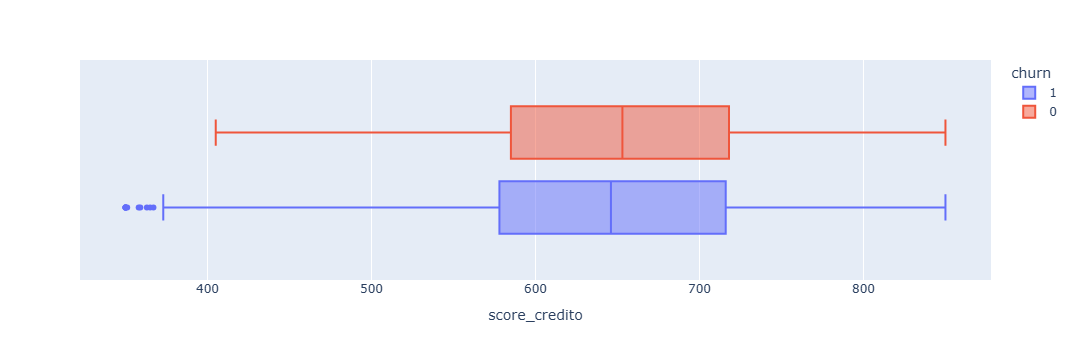

In [19]:
#analisando a distribuição do score de crédito
px.box(dados, x = 'score_credito', color = 'churn')

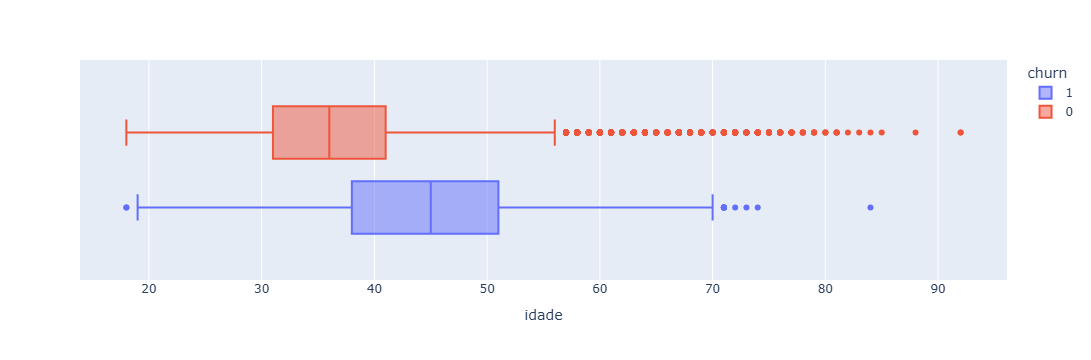

In [21]:
#analisando a distribuição de idade
px.box(dados, x = 'idade', color = 'churn')

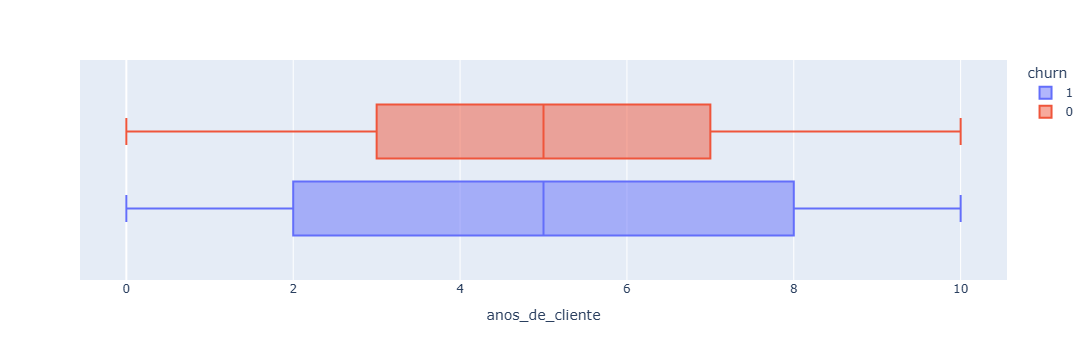

In [23]:
#analisando distribuição de tempo de contrato
px.box(dados, x = 'anos_de_cliente', color = 'churn')

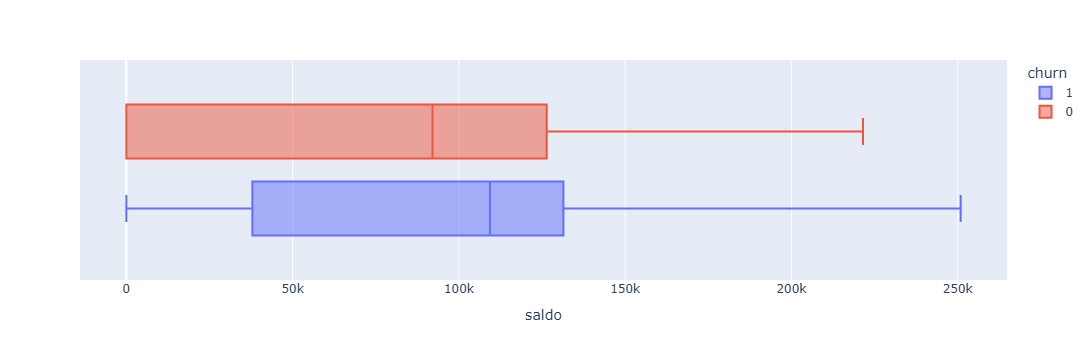

In [25]:
#analisando distirbuição de saldo em conta
px.box(dados, x = 'saldo', color = 'churn')

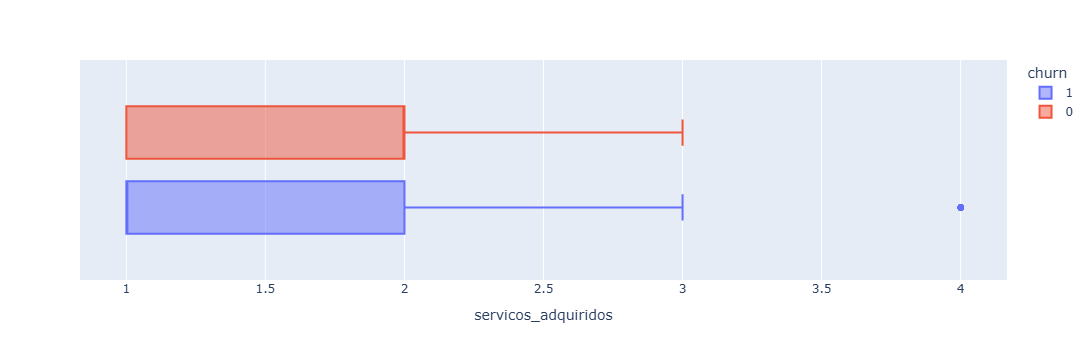

In [27]:
#analisando distirbuição de srviços adquiridos
px.box(dados, x = 'servicos_adquiridos', color = 'churn')

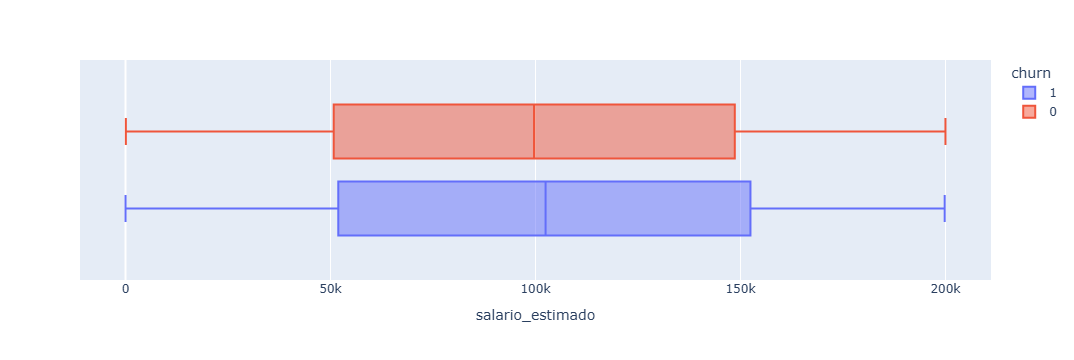

In [28]:
#analisando distribuição de saldo
px.box(dados, x = 'salario_estimado', color = 'churn')

### Etapa 4:

Para utilizar os dados nos algoritmos de Machine Learning, precisamos informar quais são as variáveis explicativas e qual é a variável alvo. Vamos separar essas variaveis


In [29]:
x = dados.drop('churn', axis = 1)
y = dados['churn']

### Etapa 5:

Variáveis categóricas que estejam em formato de texto não podem ser utilizadas diretamente nos modelos de Machine Learning. Vamos utilizar o OneHotEncoder para ajustar isso

In [30]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [31]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['sexo_biologico','pais', 'tem_cartao_credito', 'membro_ativo']
),
    remainder = 'passthrough',
    sparse_threshold=0)

In [32]:
#guardar o nome correto das colunas antes do onehotencoder
colunas = x.columns

In [33]:
x = one_hot.fit_transform(x)

In [34]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__sexo_biologico_Mulher',
       'onehotencoder__pais_Alemanha', 'onehotencoder__pais_Espanha',
       'onehotencoder__pais_França',
       'onehotencoder__tem_cartao_credito_1',
       'onehotencoder__membro_ativo_1', 'remainder__id_cliente',
       'remainder__score_credito', 'remainder__idade',
       'remainder__anos_de_cliente', 'remainder__saldo',
       'remainder__servicos_adquiridos', 'remainder__salario_estimado'],
      dtype=object)

In [35]:
#visualizando os dados após o onehotencodder
#VEJA QUE RESTA APANEAS NUMEROS NA BASE
pd.DataFrame(x, columns = one_hot.get_feature_names_out(colunas))

,onehotencoder__sexo_biologico_Mulher,onehotencoder__pais_Alemanha,onehotencoder__pais_Espanha,onehotencoder__pais_França,onehotencoder__tem_cartao_credito_1,onehotencoder__membro_ativo_1,remainder__id_cliente,remainder__score_credito,remainder__idade,remainder__anos_de_cliente,remainder__saldo,remainder__servicos_adquiridos,remainder__salario_estimado
0,1.0,0.0,0.0,1.0,1.0,1.0,15634602.0,619.0,42.0,2.0,0.00,1.0,101348.88
1,1.0,0.0,1.0,0.0,0.0,1.0,15647311.0,608.0,41.0,1.0,83807.86,1.0,112542.58
2,1.0,0.0,0.0,1.0,1.0,0.0,15619304.0,502.0,42.0,8.0,159660.80,3.0,113931.57
3,1.0,0.0,0.0,1.0,0.0,0.0,15701354.0,699.0,39.0,1.0,0.00,2.0,93826.63
4,1.0,0.0,1.0,0.0,1.0,1.0,15737888.0,850.0,43.0,2.0,125510.82,1.0,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,1.0,1.0,0.0,15606229.0,771.0,39.0,5.0,0.00,2.0,96270.64
9996,0.0,0.0,0.0,1.0,1.0,1.0,15569892.0,516.0,35.0,10.0,57369.61,1.0,101699.77
9997,1.0,0.0,0.0,1.0,0.0,1.0,15584532.0,709.0,36.0,7.0,0.00,1.0,42085.58
9998,0.0,1.0,0.0,0.0,1.0,0.0,15682355.0,772.0,42.0,3.0,75075.31,2.0,92888.52


### Etapa 6:

A variável alvo, como é do tipo categórica, também precisa passar por um tratamento similar às variáveis explicativas categóricas para que possa ser usada nos algoritmos. 

In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
label_ecoder = LabelEncoder()

In [38]:
y = label_ecoder.fit_transform(y)

In [39]:
y

array([1, 0, 1, ..., 1, 1, 0], dtype=int64)

### Etapa 7:

A separação dos dados entre conjunto de treinamento e teste é essencial para compreender se um modelo está conseguindo aprender os padrões e generalizar para novos dados. 

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, stratify = y,  random_state = 5)

### Etapa 8:

Um modelo de base é muito importante para definir um critério de comparação para modelos mais complexos.  Vamos utilizar esse modelo simples como parametro

In [42]:
from sklearn.dummy import DummyClassifier

In [43]:
dummy = DummyClassifier()
dummy.fit(x_treino, y_treino)

dummy.score(x_teste, y_teste)

0.7964

### Etapa 9:

A árvore de decisão é um algoritmo que faz as classificações a partir de decisões simples tomadas a partir dos dados.  Vamos criar um modelo de arvore de decisão e definir profundidade = 4

In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
arvore = DecisionTreeClassifier(max_depth = 4, random_state =5)
arvore.fit(x_treino, y_treino)

arvore.score(x_teste, y_teste)

0.8464

In [46]:
#visualizando nossa arvore
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

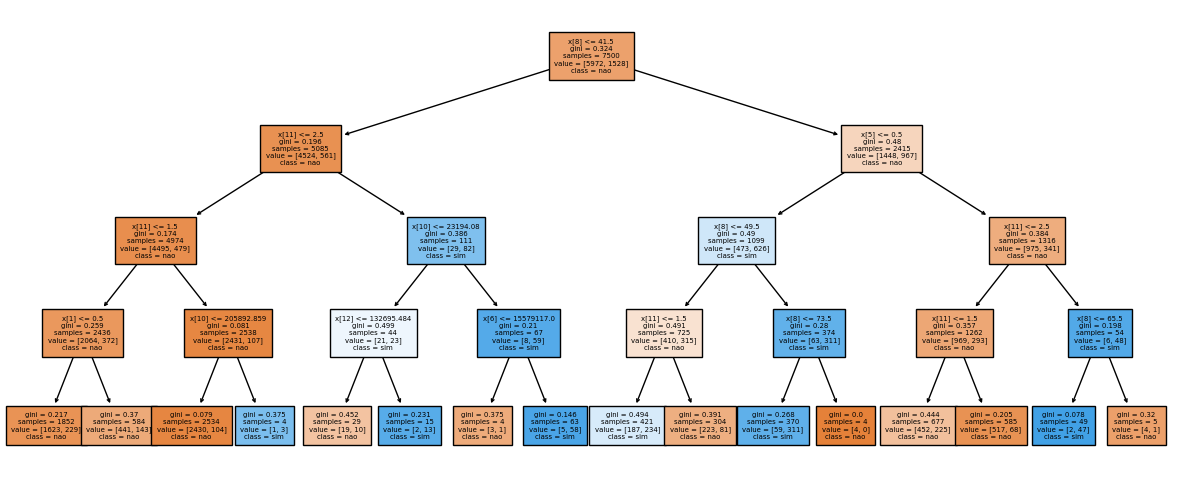

In [47]:
plt.figure(figsize = (15, 6))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 5);

### Etapa 10:

A normalização de dados é uma tarefa importante para manter todos os valores numéricos em uma mesma escala e garantir que todas as características tenham o mesmo impacto no modelo. 


In [48]:
from sklearn.preprocessing import MinMaxScaler

In [49]:
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(x_treino)

In [50]:
pd.DataFrame(x_treino_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,0.0,0.0,1.0,1.0,0.0,0.134945,0.796,0.216216,0.8,0.000000,0.333333,0.267600
1,0.0,0.0,0.0,1.0,0.0,1.0,0.388805,0.612,0.256757,0.2,0.000000,0.333333,0.338919
2,1.0,1.0,0.0,0.0,1.0,0.0,0.372064,0.634,0.256757,0.5,0.386645,0.666667,0.890516
3,1.0,0.0,0.0,1.0,1.0,0.0,0.540667,0.514,0.040541,0.0,0.000000,0.333333,0.580365
4,1.0,0.0,1.0,0.0,0.0,1.0,0.980751,0.374,0.270270,0.6,0.594774,0.000000,0.738898
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,0.0,1.0,0.0,0.0,1.0,0.0,0.440380,0.590,0.391892,0.9,0.637940,0.000000,0.609048
7496,1.0,0.0,1.0,0.0,1.0,0.0,0.670263,0.676,0.229730,0.6,0.000000,0.000000,0.127054
7497,1.0,0.0,1.0,0.0,1.0,0.0,0.480427,0.646,0.229730,0.6,0.000000,0.333333,0.492884
7498,1.0,0.0,0.0,1.0,1.0,0.0,0.261445,0.720,0.202703,0.2,0.000000,0.333333,0.364454


### Etapa 11:

Com os dados normalizados, podemos utilizar o modelo KNN, que faz cálculos de distância para encontrar os vizinhos mais próximos.

In [51]:
from sklearn.neighbors import KNeighborsClassifier

In [52]:
knn = KNeighborsClassifier()
knn.fit(x_treino_normalizado, y_treino)

KNeighborsClassifier()

In [53]:
x_teste_normalizado = normalizacao.transform(x_teste)

In [54]:
knn.score(x_teste_normalizado, y_teste)

0.8016

### Etapa 12:

Após a construção dos modelos, é o momento de comparar os resultados e selecionar aquele que tem o melhor desempenho. Avaliando a taxa de acerto dos modelos `DummyClassifier`, `DecisionTreeClassifier` e `KNeighborsClassifier` .

In [55]:
print(f'Acurácia Dummy: {dummy.score(x_teste, y_teste)}')
print(f'Acurácia Árvore: {arvore.score(x_teste, y_teste)}')
print(f'Acurácia KNN: {knn.score(x_teste_normalizado, y_teste)}')

Acurácia Dummy: 0.7964
Acurácia Árvore: 0.8464
Acurácia KNN: 0.8016


### Conclusão:

A modelo que teve a melhor acurácio na nosso exemplo foi a árvore de decisão, com acuráricia de 85%.


### Utilizar o modelo para prever:

Agora vamos entrar com novo cliente e checar o que o modelo tem de retorno

In [77]:
#Vamos inserir novos dados no nosso modelo
novo_dado = pd.DataFrame({
    'id_cliente': [1],
    'score_credito': [850],
    'pais':['França'],
    'sexo_biologico':['Homem'],
    'idade': [27],
    'anos_de_cliente': [3],
    'saldo': [56000],
    'servicos_adquiridos': [1],
    'tem_cartao_credito': [1],
    'membro_ativo': [1],
    'salario_estimado': [85270.00]
})

In [78]:
#utilizando o onehot e nosso modelo para fazer a predição
novo_dado = one_hot.transform(novo_dado)
pred = arvore.predict(novo_dado)[0]

In [79]:
mapa = {
    0: "Baixo risco de churn",
    1: "Alto risco de churn"
}

print(mapa[pred])

Baixo risco de churn


#### muito obrigado

## Por Fernando Humberto

In [82]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
